## The Dataset

we will be using a CSV file titled `premier-player-23-24.csv`, which contains information on all players in Premier League season 2023-2024. The dataset includes the following columns:
- `Player`:Name of the player.
- `Nation`:The player's nationality.
- `Pos`:The position(s) the player typically plays (e.g., FW, MF, DF, GK).
- `Age`:The player's age.
- `MP`:Matches Played – The number of games the player appeared in.
- `Starts`:The number of games the player started.
- `Min`:Total minutes played.
- `90s (90s Played)`:The equivalent of 90-minute matches played by the player (e.g., 1.5 = 135 minutes).
- `Gls(Goals)`:Total number of goals scored by the player.
- `Ast(Assists)`: Total number of assists made by the player.
- `G+A (Goals + Assists)`:  Total number of goals and assists combined.
- `G-PK (Goals - Penalty Kicks)`:Total number of goals scored excluding penalty kicks.
- `PK (Penalty Kicks)`:Number of penalty goals scored by the player.
- `PKatt (Penalty Kicks Attempted)`:Number of penalty kicks attempted by the player.
- `CrdY (Yellow Cards)`:Number of yellow cards received by the player.
- `CrdR (Red Cards)`:Number of red cards received by the player.
- `xG (Expected Goals)`:The expected number of goals from the player's shots.
- `npxG (Non-Penalty Expected Goals)`:Expected goals excluding penalties.
- `xAG (Expected Assists)`:The expected number of assists from the player's passes.
- `npxG+xAG (Non-Penalty xG + xAG)`:Total of non-penalty expected goals and expected assists.
- `PrgC (Progressive Carries)`:Number of times the player carried the ball forward.
- `PrgP (Progressive Passes)`:Number of passes made by the player that moved the ball forward.
- `PrgR (Progressive Runs)`:Number of times the player made runs forward with the ball.
- `Gls_90`: Goals per 90 minutes.
- `Ast_90`:Assists per 90 minutes.
- `G+A_90`:Goals + Assists per 90 minutes.
- `G-PK_90`:Non-penalty goals per 90 minutes.
- `G+A-PK_90`:Goals + Assists (excluding penalties) per 90 minutes.
- `xG_90`:Expected Goals per 90 minutes.
- `xAG_90`:Expected Assists per 90 minutes.
- `xG+xAG_90`:Expected Goals + Expected Assists per 90 minutes.
- `npxG_90`:Non-penalty Expected Goals per 90 minutes.
- `npxG+xAG_90`: Non-penalty Expected Goals + Expected Assists per 90 minutes.


## Getting started

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os    

In [2]:
# File path
file_path = "C:/Users/nwf15/Downloads/premier-player-23-24.csv"

we going to check if the file exists before proceeding

In [3]:
if not os.path.exists(file_path):
    print("File not found! Please check the file path.")
else:
    
        # Load the data
        df = pd.read_csv(file_path)
       

# We will process the dataset by resolving missing data, eliminating duplicates, verifying, and saving the cleaned data.

Visualizing missing data...


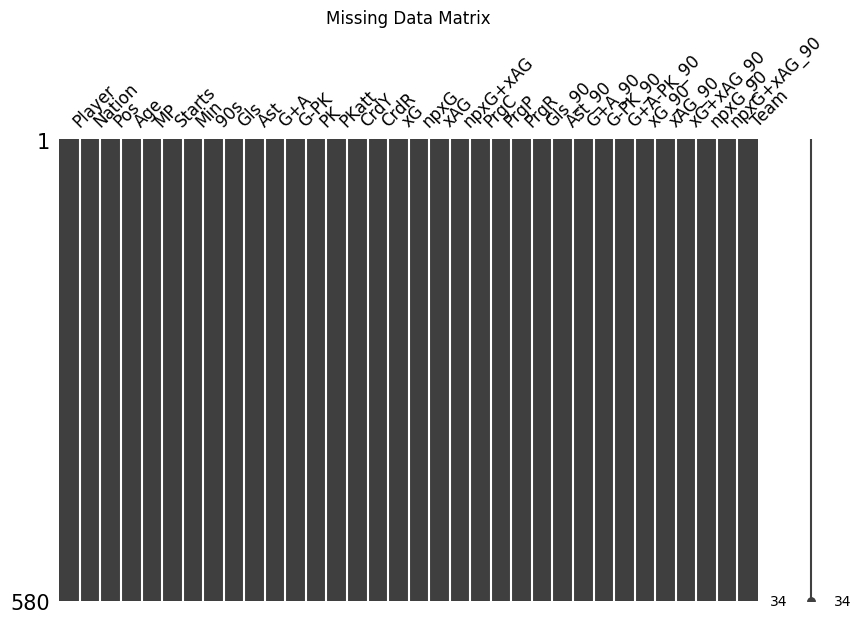

In [ ]:
        print("Visualizing missing data...")
          msno.matrix(df, figsize=(10, 6), fontsize=12)
          plt.title("Missing Data Matrix")
          plt.show()


As we can see there is no missing data

- Here we going to delete the dublicate records if there was any dublicts

In [5]:
        duplicates_count = df.duplicated().sum()
        df = df.drop_duplicates()
        print(f"Removed {duplicates_count} duplicate records.")

Removed 0 duplicate records.


In [6]:
df.dtypes

Player          object
Nation          object
Pos             object
Age            float64
MP               int64
Starts           int64
Min            float64
90s            float64
Gls            float64
Ast            float64
G+A            float64
G-PK           float64
PK             float64
PKatt          float64
CrdY           float64
CrdR           float64
xG             float64
npxG           float64
xAG            float64
npxG+xAG       float64
PrgC           float64
PrgP           float64
PrgR           float64
Gls_90         float64
Ast_90         float64
G+A_90         float64
G-PK_90        float64
G+A-PK_90      float64
xG_90          float64
xAG_90         float64
xG+xAG_90      float64
npxG_90        float64
npxG+xAG_90    float64
Team            object
dtype: object

As we can see, some data types are incorrect, and this has to be fixed. 

# The data types we need change is
`Age`
`Min`
`Gls`
`Ast`
`G+A`
`G-PK`
`PK`
`PKatt`
`CrdY`
`CrdR` 
`PrgC`
`PrgP`
`PrgR`

In [ ]:
        # 3. Reformatting/Converting Data Types
        df['Age']=df['Age'].astype(int)
        df['Gls']=df['Gls'].astype(int)
        df['Min']=df['Min'].astype(int)
        df['Ast']=df['Ast'].astype(int)
        df['G+A']=df['G+A'].astype(int)
        df['G-PK']=df['G-PK'].astype(int)
        df['PK']=df['PK'].astype(int)
        df['PKatt']=df['PKatt'].astype(int)
        df['CrdY']=df['CrdY'].astype(int)
        df['CrdR']=df['CrdR'].astype(int)
        df['PrgC']=df['PrgC'].astype(int)
        df['PrgP']=df['PrgC'].astype(int)
        df['PrgR']=df['PrgC'].astype(int)


In [ ]:
df.dtypes

Player          object
Nation          object
Pos             object
Age            float64
MP               int64
Starts           int64
Min            float64
90s            float64
Gls            float64
Ast            float64
G+A            float64
G-PK           float64
PK             float64
PKatt          float64
CrdY           float64
CrdR           float64
xG             float64
npxG           float64
xAG            float64
npxG+xAG       float64
PrgC           float64
PrgP           float64
PrgR           float64
Gls_90         float64
Ast_90         float64
G+A_90         float64
G-PK_90        float64
G+A-PK_90      float64
xG_90          float64
xAG_90         float64
xG+xAG_90      float64
npxG_90        float64
npxG+xAG_90    float64
Team            object
dtype: object

now we move on after we fixed the data types

# We will examine the dataset to see if any negative values exist.

In [33]:
        # 4. Validate Data
        # Check for negative values
        negative_values = {col: df[df[col] < 0].shape[0] for col in ["Age", "Gls", "xG_90", "Min"] if (df[col] < 0).any()}
        print("Negative value counts:", negative_values)


Negative value counts: {}


# Now we going to check for invalid ranges 

In [37]:
        invalid_age = df[(df['Age'] < 16) | (df['Age'] > 50)]
        print("Invalid ages found:\n", invalid_age)

Invalid ages found:
           Player   Nation Pos  Age  MP  Starts  Min  90s  Gls  Ast  ...  \
171  Mikey Moore  eng ENG  MF   15   2       0    4  0.0    0    0  ...   

     Ast_90  G+A_90  G-PK_90  G+A-PK_90  xG_90  xAG_90  xG+xAG_90  npxG_90  \
171     0.0     0.0      0.0        0.0    0.0     0.0        0.0      0.0   

     npxG+xAG_90               Team  
171          0.0  Tottenham Hotspur  

[1 rows x 34 columns]


# Save the file

In [40]:
        processed_file_path = 'processed_data.csv'
        df.to_csv(processed_file_path, index=False)
        print(f"Data saved to {processed_file_path}")

Data saved to processed_data.csv


# We going now to analyzing the data

In [30]:
        # Function to analyze specific teams
        def analyze_teams(data, teams):
            filtered_data = data[data['Team'].isin(teams)]
            metrics = filtered_data.groupby('Team').agg(
                avg_goals=('Gls', 'mean'),
                avg_assists=('Ast', 'mean'),
                avg_minutes=('Min', 'mean'),
                total_goals=('Gls', 'sum'),
                total_assists=('Ast', 'sum')
            ).sort_values(by='avg_goals', ascending=False)
            return metrics


# Calculate total goals scored by top 5 teams

In [31]:
        # Calculate total goals scored by each team
        team_goals = df.groupby("Team")["Gls"].sum().sort_values(ascending=False)
        print("Top 5 teams by total goals scored:")
        print(team_goals.head())


Top 5 teams by total goals scored:
Team
Manchester City     94.0
Arsenal             86.0
Newcastle United    83.0
Liverpool           80.0
Chelsea             76.0
Name: Gls, dtype: float64


In [32]:
       
        teams_of_interest = ['Manchester City', 'Arsenal', 'Liverpool']
        team_performance = analyze_teams(df, teams_of_interest)
        print("Team performance metrics:")
        print(team_performance)
        


Team performance metrics:
                 avg_goals  avg_assists  avg_minutes  total_goals  \
Team                                                                
Manchester City   3.760000         2.76      1502.96         94.0   
Arsenal           3.440000         2.48      1503.52         86.0   
Liverpool         2.666667         2.00      1247.80         80.0   

                 total_assists  
Team                            
Manchester City           69.0  
Arsenal                   62.0  
Liverpool                 60.0  


# Top 10 players goals

In [25]:
        top_xg_players = df[df['Gls'] >= 10].sort_values('Gls', ascending=False).head(10)
        print("Top 10 players with the highest xG (minimum 10 goals):")
        print(top_xg_players[['Player', 'Team', 'Gls', 'xG']])

Top 10 players with the highest xG (minimum 10 goals):
              Player               Team   Gls    xG
6     Erling Haaland    Manchester City  27.0  29.2
83       Cole Palmer            Chelsea  22.0  18.2
117   Alexander Isak   Newcastle United  21.0  20.3
204    Ollie Watkins        Aston Villa  19.0  16.8
1         Phil Foden    Manchester City  19.0  10.3
369  Dominic Solanke        Bournemouth  19.0  19.6
28     Mohamed Salah          Liverpool  18.0  21.2
146    Son Heung-min  Tottenham Hotspur  17.0  12.0
237     Jarrod Bowen    West Ham United  16.0  11.6
59       Bukayo Saka            Arsenal  16.0  15.5


# Top 10 players assists

In [27]:
        top_xag_players = df[df['Ast'] >= 10].sort_values('Ast', ascending=False).head(10)
        print("\nTop 10 players with the highest xAG (minimum 10 assists):")
        print(top_xag_players[['Player', 'Team', 'Ast', 'xAG']])



Top 10 players with the highest xAG (minimum 10 assists):
              Player               Team   Ast   xAG
204    Ollie Watkins        Aston Villa  13.0   7.3
83       Cole Palmer            Chelsea  11.0  11.1
13   Kevin De Bruyne    Manchester City  10.0  11.5
28     Mohamed Salah          Liverpool  10.0  11.8
57   Martin Ødegaard            Arsenal  10.0   9.6
114   Anthony Gordon   Newcastle United  10.0   8.0
118  Kieran Trippier   Newcastle United  10.0   7.5
146    Son Heung-min  Tottenham Hotspur  10.0  11.8
154  Brennan Johnson  Tottenham Hotspur  10.0   8.1
338      Pascal Groß           Brighton  10.0   8.1


# Top 10 players with the highest xG who have scored at least 10 goals

In [23]:
        top_xg_players = df[df['Gls'] >= 10].sort_values('xG', ascending=False).head(10)
        print("Top 10 players with the highest xG (minimum 10 goals):")
        print(top_xg_players[['Player', 'Team', 'Gls', 'xG']])

Top 10 players with the highest xG (minimum 10 goals):
              Player              Team   Gls    xG
6     Erling Haaland   Manchester City  27.0  29.2
28     Mohamed Salah         Liverpool  18.0  21.2
117   Alexander Isak  Newcastle United  21.0  20.3
369  Dominic Solanke       Bournemouth  19.0  19.6
82   Nicolas Jackson           Chelsea  14.0  18.6
83       Cole Palmer           Chelsea  22.0  18.2
204    Ollie Watkins       Aston Villa  19.0  16.8
32      Darwin Núñez         Liverpool  11.0  16.3
59       Bukayo Saka           Arsenal  16.0  15.5
3     Julián Álvarez   Manchester City  11.0  13.0


# Top 10 players with the highest xAG who have provided at least 10 assists

In [24]:
        top_xag_players = df[df['Ast'] >= 10].sort_values('xAG', ascending=False).head(10)
        print("\nTop 10 players with the highest xAG (minimum 10 assists):")
        print(top_xag_players[['Player', 'Team', 'Ast', 'xAG']])



Top 10 players with the highest xAG (minimum 10 assists):
                 Player               Team   Ast   xAG
28        Mohamed Salah          Liverpool  10.0  11.8
146       Son Heung-min  Tottenham Hotspur  10.0  11.8
13      Kevin De Bruyne    Manchester City  10.0  11.5
83          Cole Palmer            Chelsea  11.0  11.1
57      Martin Ødegaard            Arsenal  10.0   9.6
453  Morgan Gibbs-White  Nottingham Forest  10.0   8.4
154     Brennan Johnson  Tottenham Hotspur  10.0   8.1
338         Pascal Groß           Brighton  10.0   8.1
114      Anthony Gordon   Newcastle United  10.0   8.0
118     Kieran Trippier   Newcastle United  10.0   7.5


# Age and Performance Analysis

<Axes: xlabel='Age', ylabel='Gls'>

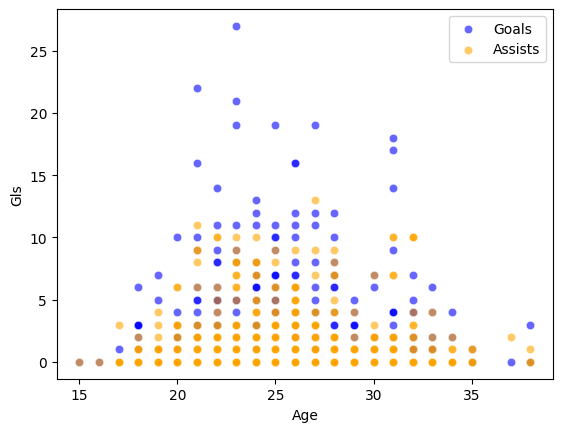

In [41]:
        age_performance = df[['Age', 'Gls', 'Ast', 'Min']]
        sns.scatterplot(data=age_performance, x='Age', y='Gls', alpha=0.6, color='blue', label='Goals')
        sns.scatterplot(data=age_performance, x='Age', y='Ast', alpha=0.6, color='orange', label='Assists')

# Discipline Analysis

<Axes: xlabel='Team'>

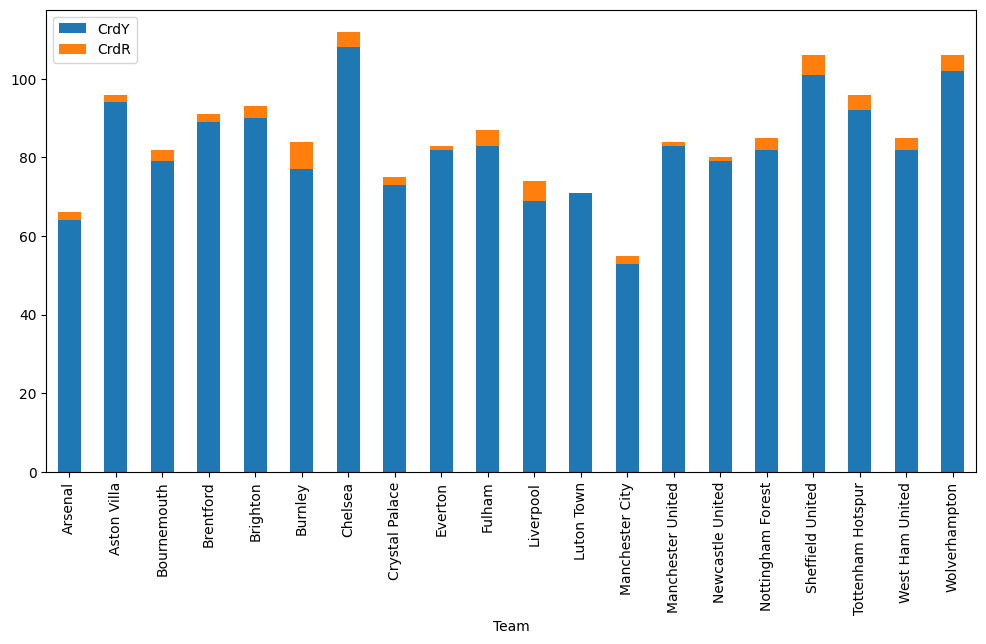

In [42]:
        discipline_by_team = df.groupby('Team')[['CrdY', 'CrdR']].sum()
        discipline_by_pos = df.groupby('Pos')[['CrdY', 'CrdR']].sum()
        discipline_by_team.plot(kind='bar', stacked=True, figsize=(12, 6))

 # Team Style of Play (Progressive Metrics)
        


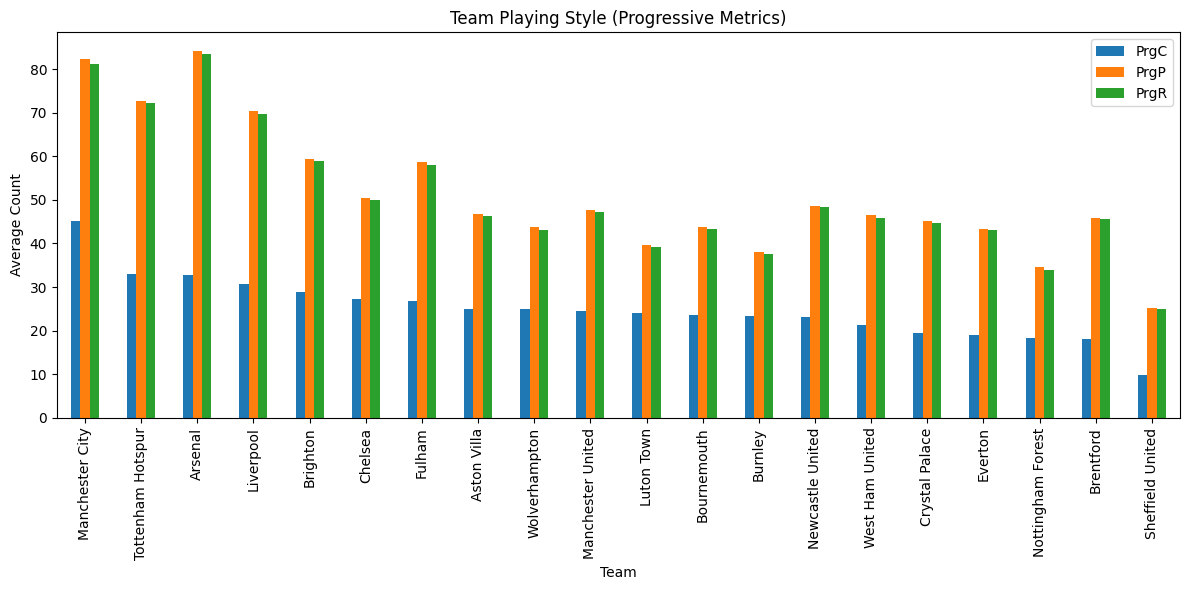

In [43]:
        team_play_style = df.groupby('Team')[['PrgC', 'PrgP', 'PrgR']].mean()
        team_play_style.sort_values('PrgC', ascending=False).plot(kind='bar', figsize=(12, 6))
        plt.title('Team Playing Style (Progressive Metrics)')
        plt.ylabel('Average Count')
        plt.xlabel('Team')
        plt.tight_layout()
        plt.show()
        

# Team Efficiency: Actual Goals vs Expected Goals

<Axes: xlabel='Team'>

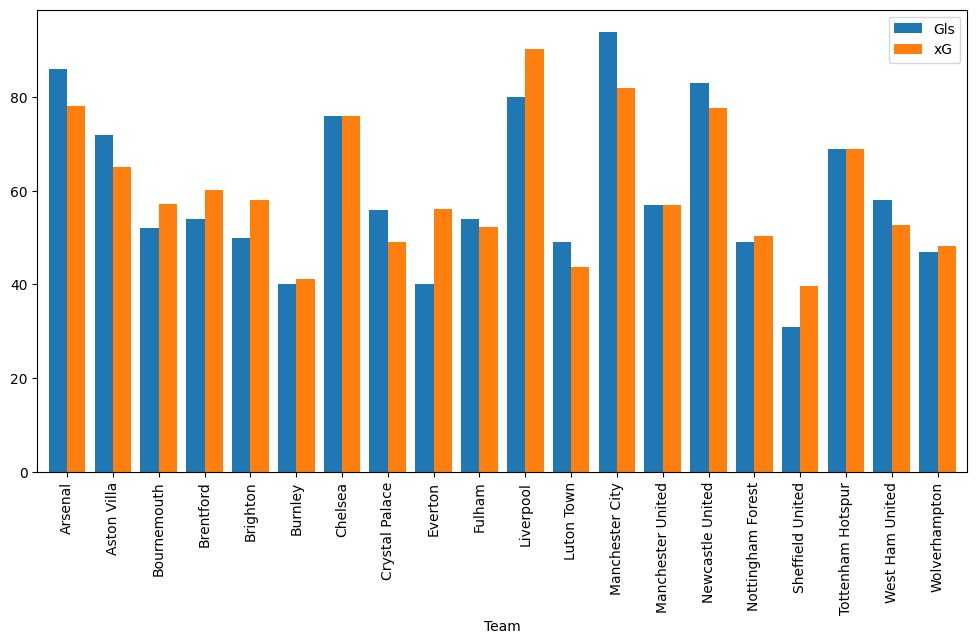

In [44]:
        team_efficiency = df.groupby('Team')[['Gls', 'xG']].sum()
        team_efficiency['Efficiency_Ratio'] = team_efficiency['Gls'] / team_efficiency['xG']
        team_efficiency[['Gls', 'xG']].plot(kind='bar', figsize=(12, 6), width=0.8)

# Efficiency Metrics: Goal Conversion Rate and Assist Over/Underperformance

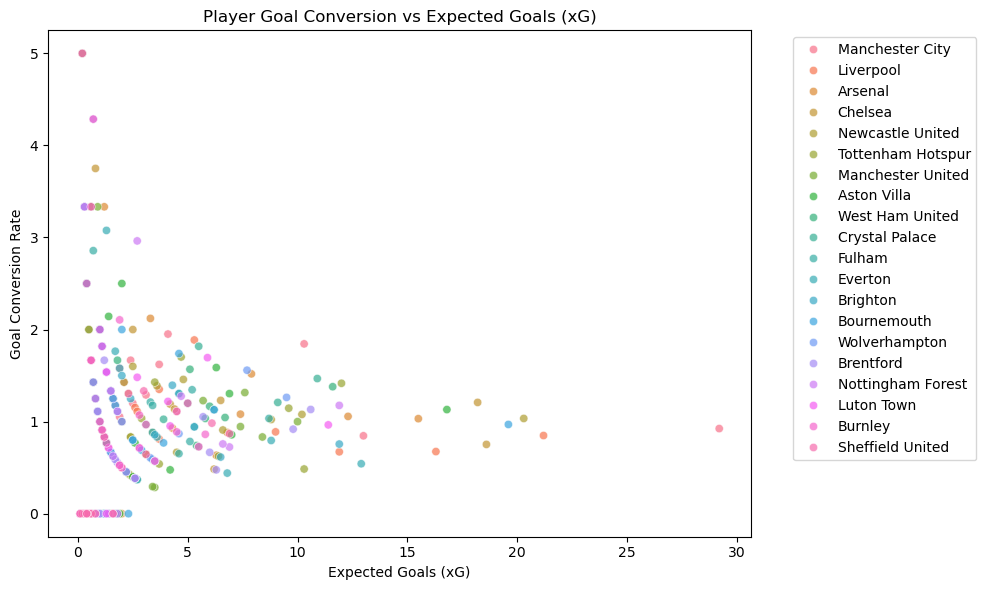

In [88]:
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=efficiency_metrics, x='xG', y='Goal_Conversion', hue='Team', alpha=0.7)
        plt.title('Player Goal Conversion vs Expected Goals (xG)')
        plt.xlabel('Expected Goals (xG)')
        plt.ylabel('Goal Conversion Rate')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

# Total Goals by Team

C:\Users\nwf15\AppData\Local\Temp\ipykernel_8572\923336639.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_goals.index, y=team_goals.values, palette="viridis")


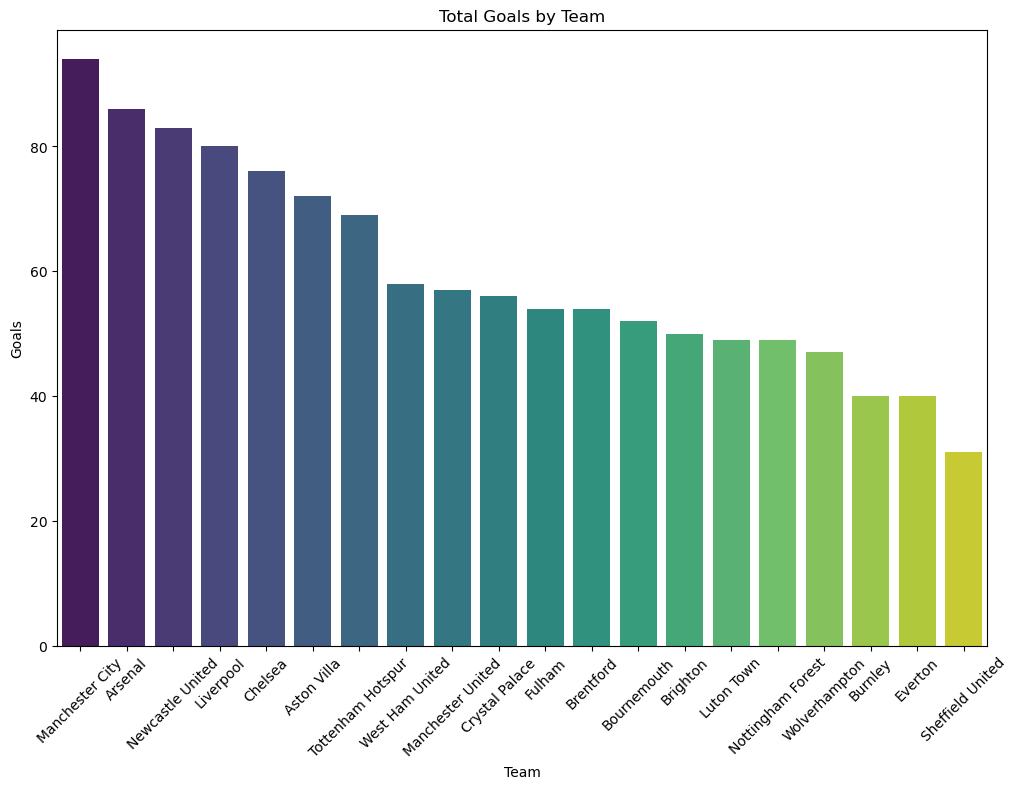

In [94]:
        # Visualization: Total goals by team
        plt.figure(figsize=(12, 8))
        sns.barplot(x=team_goals.index, y=team_goals.values, palette="viridis")
        plt.xticks(rotation=45)
        plt.title("Total Goals by Team")
        plt.ylabel("Goals")
        plt.xlabel("Team")
        plt.show()

# Distribution of Player Nationalities

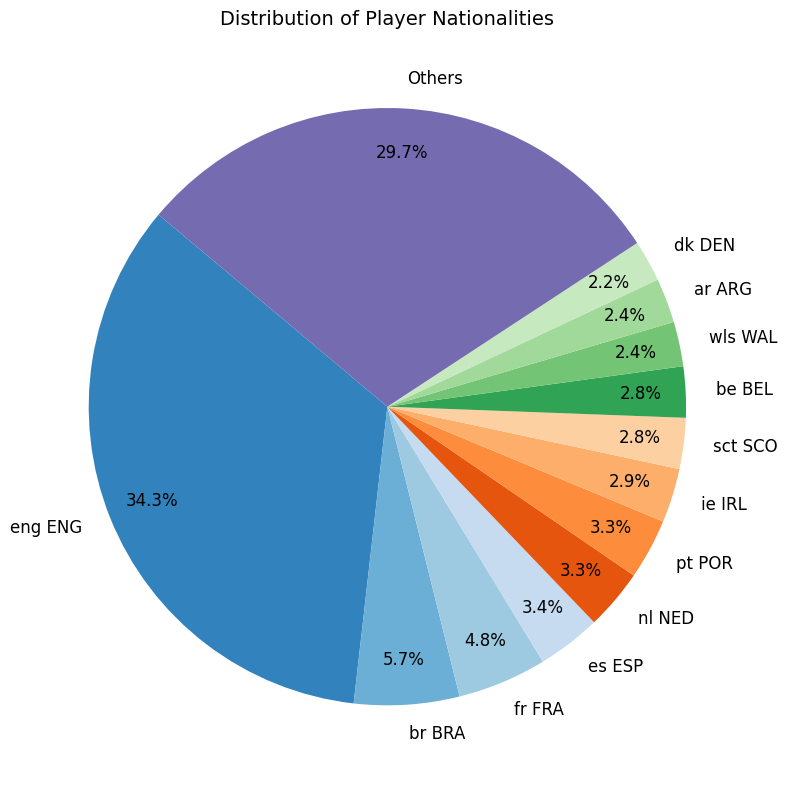

In [38]:
        # Group smaller categories into "Others"
        threshold = 2  # Set a percentage threshold for grouping
        nationality_counts = df['Nation'].value_counts(normalize=True) * 100
        major_nationalities = nationality_counts[nationality_counts > threshold]
        others = nationality_counts[nationality_counts <= threshold].sum()
        
        # Create a new Series with "Others" included
        pie_data = pd.concat([major_nationalities, pd.Series({'Others': others})])
        
       
        plt.figure(figsize=(10, 8))
        pie_data.plot(
            kind='pie',
            autopct='%1.1f%%',
            startangle=140,
            colors=sns.color_palette('tab20c', len(pie_data)),
            textprops={'fontsize': 12},
            pctdistance=0.85
        )
        plt.title("Distribution of Player Nationalities", fontsize=14)
        plt.ylabel("")  # Hide y-axis label
        plt.tight_layout()
        plt.show()


# Age Distribution

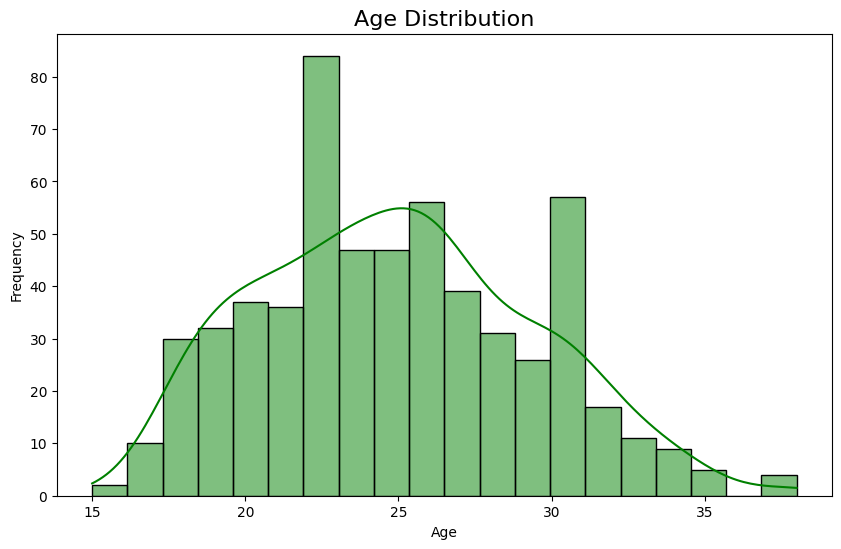

In [46]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, color='green')
plt.title('Age Distribution', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()